<a href="https://colab.research.google.com/github/ayman-dayf/HuSCF-Comm/blob/main/ReRun_HuSCF_Add_Comm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ayman-dayf/Hu-Comm.git
%cd Hu-Comm


Cloning into 'Hu-Comm'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 123 (delta 14), reused 0 (delta 0), pack-reused 92 (from 1)
Receiving objects: 100% (123/123), 135.74 MiB | 14.97 MiB/s, done.
Resolving deltas: 100% (16/16), done.
Updating files: 100% (68/68), done.
/content/Hu-Comm


In [2]:
!pip install -q pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!pip install -q --upgrade pip

!pip install -q \
    torch==2.4.1+cu118 \
    torchvision==0.19.1+cu118 \
    numpy==1.26.4 \
    PyYAML==6.0.2 \
    scikit-learn==1.6.1 \
    matplotlib==3.9.2 \
    scipy==1.14.1 \
    pandas==2.2.3 \
    --extra-index-url https://download.pytorch.org/whl/cu118

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.2 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement torch==2.4.1+cu118 (from versions: 2.5.0, 2.5.0+cu118, 2.5.1, 2.5.1+cu118, 2.6.0, 2.6.0+cu118, 2.7.0, 2.7.0+cu118, 2.7.1, 2.7.1+cu118, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0, 2.12.1, 2.13.0, 2.14.0)
ERROR: No matching distribution found for torch==2.4.1+cu118


In [4]:
# 4. Verify PyTorch/GPU
%cd /content/HuSCF-GAN

import torch
import torchvision
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


[Errno 2] No such file or directory: '/content/HuSCF-GAN'
/content/Hu-Comm
PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
NumPy: 2.1.3
CUDA available: False


In [5]:
# 5. Check the configuration

!cat configs.yaml


# Scenario guide:
# - Scenario 1 & 2: IID / non-IID Single-Domain
#     → Only ONE of the num_*_clients should be non-zero
#
# - Scenario 3, 4 & 5: IID / non-IID / Highly non-IID Two-Domain
#     → Exactly TWO of the num_*_clients should be non-zero
#
# - Scenario 6: IID Multi-Domain
#     → ALL num_*_clients should be non-zero (none should be zero)

clients:
  num_digit_clients: 2         #  MNIST
  num_fashion_clients: 2       #  Fashion-MNIST
  num_kmnist_clients: 2       #  Kuzushiji-MNIST
  num_notmnist_clients: 2      #  NotMNIST

training:
  batch_size: 64               # Batch size for local training

experiment:
  scenario: 6                  # Set from 1 to 6 based on experiment type

optimizer:
  learning_rate: 0.0002
  betas:
    - 0.5
    - 0.999

settings:
  local_epochs: 1
  num_rounds: 1


In [6]:
# 6. Import
import torch
import yaml

print("CUDA:", torch.cuda.is_available())

with open("configs.yaml") as f:
    config = yaml.safe_load(f)

print(config)


CUDA: False
{'clients': {'num_digit_clients': 2, 'num_fashion_clients': 2, 'num_kmnist_clients': 2, 'num_notmnist_clients': 2}, 'training': {'batch_size': 64}, 'experiment': {'scenario': 6}, 'optimizer': {'learning_rate': 0.0002, 'betas': [0.5, 0.999]}, 'settings': {'local_epochs': 1, 'num_rounds': 1}}


In [7]:

from models import get_models
from Data import data

print("Imports successful.")


Imports successful.


In [8]:
!python train.py

Generation 1/1000 , Latency=3.438878561322677 s
Generation 2/1000 , Latency=3.401665788190476 s
Generation 3/1000 , Latency=3.3538731028571425 s
Generation 4/1000 , Latency=3.330240757237429 s
Generation 5/1000 , Latency=3.2910270185707624 s
Generation 6/1000 , Latency=3.2837472422777223 s
Generation 7/1000 , Latency=3.2782084399920084 s
Generation 8/1000 , Latency=3.275177680372961 s
Generation 9/1000 , Latency=3.2721469207539124 s
Generation 10/1000 , Latency=3.2721469207539124 s
Generation 11/1000 , Latency=3.2721469207539124 s
Generation 12/1000 , Latency=3.2721469207539124 s
Generation 13/1000 , Latency=3.2721469207539124 s
Generation 14/1000 , Latency=3.2721469207539124 s
Generation 15/1000 , Latency=3.2721469207539124 s
Generation 16/1000 , Latency=3.2721469207539124 s
Generation 17/1000 , Latency=3.2721469207539124 s
Generation 18/1000 , Latency=3.2721469207539124 s
Generation 19/1000 , Latency=3.2721469207539124 s
Generation 20/1000 , Latency=3.2721469207539124 s
Generation 21

In [9]:
!pip install -q pandas numpy matplotlib seaborn


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TRACE = "Results/Communication/packets.jsonl"

df = pd.read_json(TRACE, lines=True)

print("Packets:", len(df))
print("Total bytes:", df["serialized_bytes"].sum())
print("Total MB:", df["serialized_bytes"].sum() / 1024**2)

df.head()


Packets: 6424
Total bytes: 17441634704
Total MB: 16633.639053344727


,timestamp,round,epoch,batch,direction,client_id,model,stage,shape,dtype,numel,payload_bytes,serialized_bytes,mean,std,min,max
0,2026-09-13 22:33:04.143256664,0,0,0,client_to_core,0,generator,client_gen_to_server,"[64, 128, 14, 14]",torch.float32,1605632,6422528,6422566,0.395738,0.588762,0.0,5.364819
1,2026-09-13 22:33:04.153354406,0,0,0,client_to_core,1,generator,client_gen_to_server,"[64, 256, 7, 7]",torch.float32,802816,3211264,3211302,0.400679,0.582156,0.0,4.677165
2,2026-09-13 22:33:04.257587432,0,0,0,client_to_core,2,generator,client_gen_to_server,"[64, 128, 14, 14]",torch.float32,1605632,6422528,6422566,0.396140,0.585589,0.0,5.235937
3,2026-09-13 22:33:04.267500638,0,0,0,client_to_core,3,generator,client_gen_to_server,"[64, 256, 7, 7]",torch.float32,802816,3211264,3211302,0.400494,0.582645,0.0,4.354344
4,2026-09-13 22:33:04.370269537,0,0,0,client_to_core,4,generator,client_gen_to_server,"[64, 128, 14, 14]",torch.float32,1605632,6422528,6422566,0.395623,0.585687,0.0,4.940999


In [11]:
summary = pd.DataFrame({
    "packets": [len(df)],
    "bytes": [df["serialized_bytes"].sum()],
    "MB": [df["serialized_bytes"].sum() / 1024**2],
    "mean_packet_bytes": [df["serialized_bytes"].mean()],
    "median_packet_bytes": [df["serialized_bytes"].median()],
    "max_packet_bytes": [df["serialized_bytes"].max()],
})

summary


,packets,bytes,MB,mean_packet_bytes,median_packet_bytes,max_packet_bytes
0,6424,17441634704,16633.639053,2.715074e+06,1605670.0,12845094


In [12]:
direction = (
    df.groupby("direction")["serialized_bytes"]
      .agg(["count", "sum", "mean", "median"])
      .sort_values("sum", ascending=False)
)

direction["MB"] = direction["sum"] / 1024**2

direction


,count,sum,mean,median,MB
direction,,,,,
core_to_client,3208,9199803440,2.867769e+06,589862.0,8773.616257
client_to_core,3216,8241831264,2.562758e+06,1605670.0,7860.022797


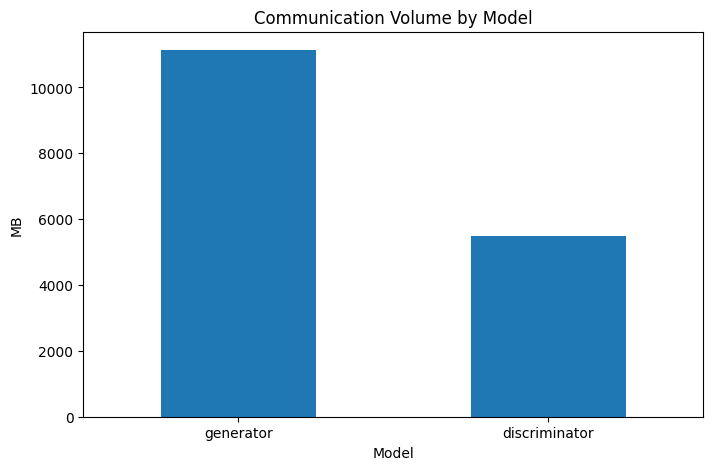

In [13]:
model_traffic = (
    df.groupby("model")["serialized_bytes"]
      .sum()
      .sort_values(ascending=False)
)

model_traffic_mb = model_traffic / 1024**2

model_traffic_mb.plot(
    kind="bar",
    figsize=(8, 5),
    title="Communication Volume by Model"
)

plt.ylabel("MB")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.show()


In [14]:
stage_stats = (
    df.groupby("stage")["serialized_bytes"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

stage_stats["MB"] = stage_stats["sum"] / 1024**2

stage_stats


,count,sum,mean,MB
stage,,,,
server_gen_to_client_gen2,808,7784134640,9633830.0,7423.529282
client_disc_to_server,2408,4349748592,1806374.0,4148.243515
client_gen_to_server,808,3892082672,4816934.0,3711.779282
server_disc_to_client_disc2,2400,1415668800,589862.0,1350.086975


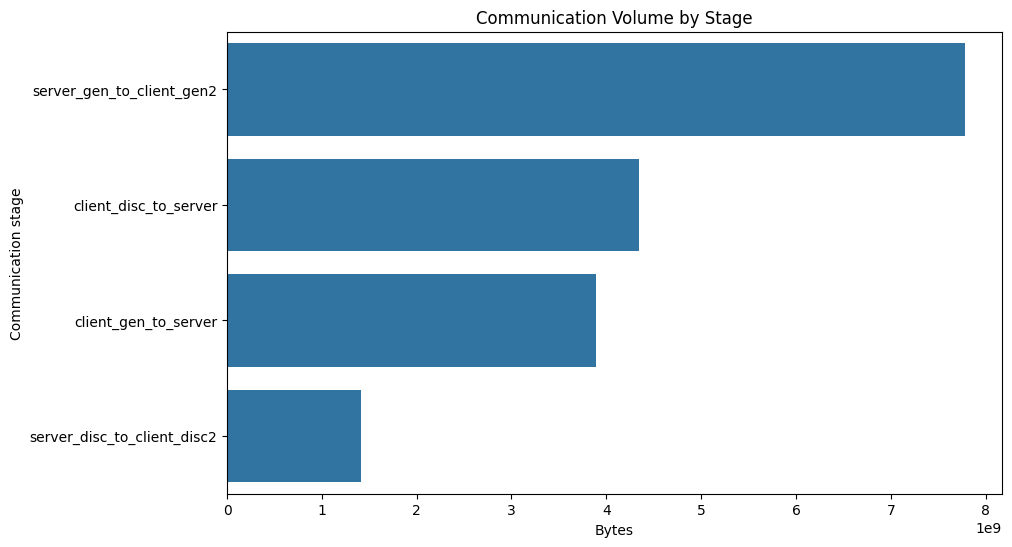

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=(
        df.groupby("stage")["serialized_bytes"]
          .sum()
          .reset_index()
          .sort_values("serialized_bytes", ascending=False)
    ),
    y="stage",
    x="serialized_bytes"
)

plt.xlabel("Bytes")
plt.ylabel("Communication stage")
plt.title("Communication Volume by Stage")

plt.show()


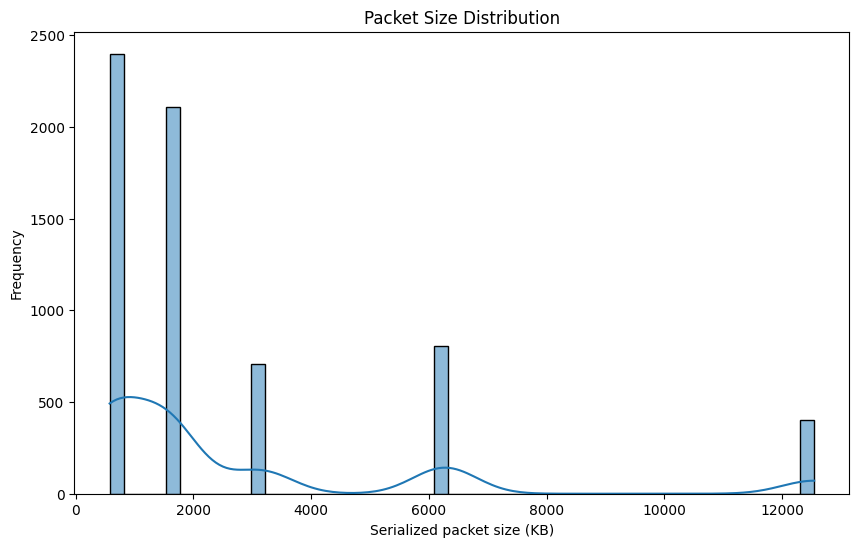

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["serialized_bytes"] / 1024,
    bins=50,
    kde=True
)

plt.xlabel("Serialized packet size (KB)")
plt.ylabel("Frequency")
plt.title("Packet Size Distribution")

plt.show()


In [17]:
client_traffic = (
    df.groupby("client_id")["serialized_bytes"]
      .sum()
      .sort_values(ascending=False)
)

client_traffic.head(20) / 1024**2


,serialized_bytes
client_id,
6,2637.15410
1,2176.24785
5,2176.24785
3,2176.24785
2,1866.93535
0,1866.93535
4,1866.93535
7,1866.93535


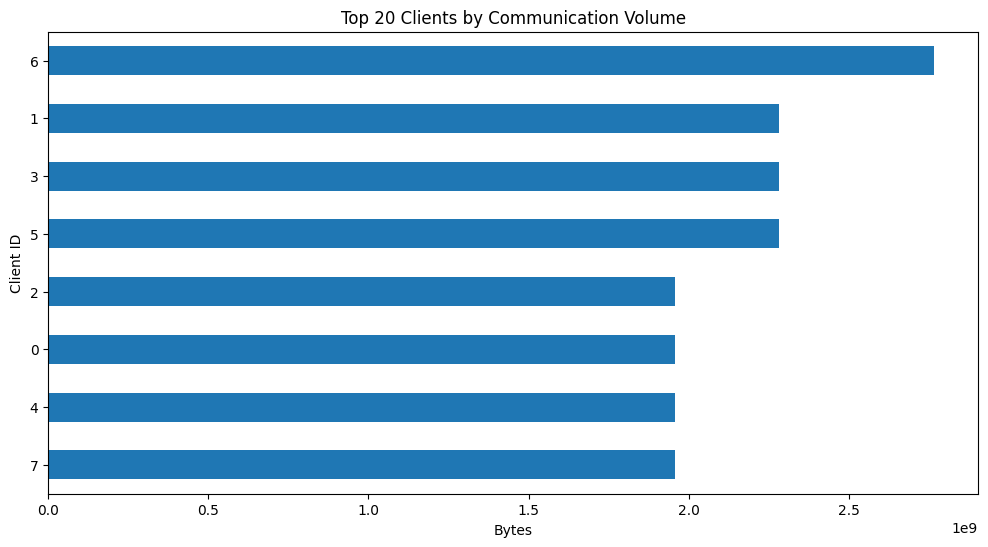

In [18]:
plt.figure(figsize=(12, 6))

client_traffic.head(20).sort_values().plot(
    kind="barh"
)

plt.xlabel("Bytes")
plt.ylabel("Client ID")
plt.title("Top 20 Clients by Communication Volume")

plt.show()


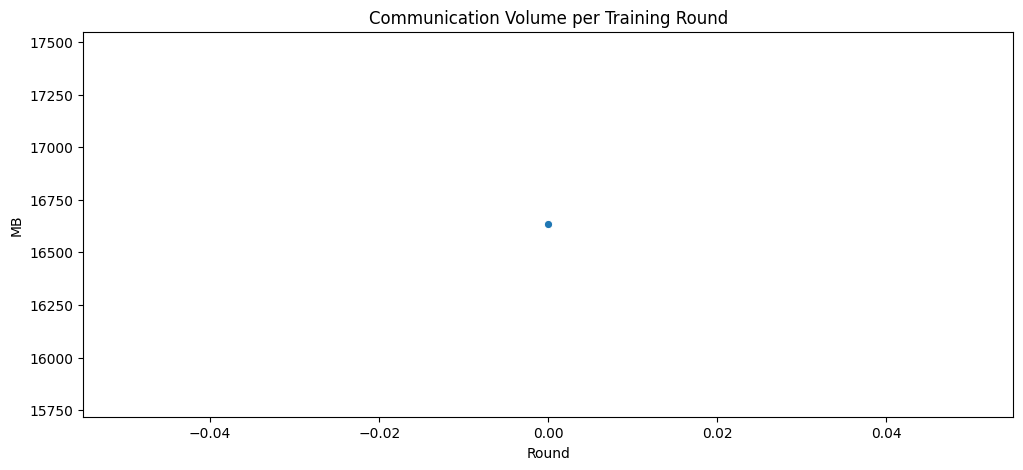

In [19]:
round_traffic = (
    df.groupby("round")["serialized_bytes"]
      .sum()
      .reset_index()
)

round_traffic["MB"] = (
    round_traffic["serialized_bytes"] / 1024**2
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=round_traffic,
    x="round",
    y="MB",
    marker="o"
)

plt.title("Communication Volume per Training Round")
plt.xlabel("Round")
plt.ylabel("MB")

plt.show()


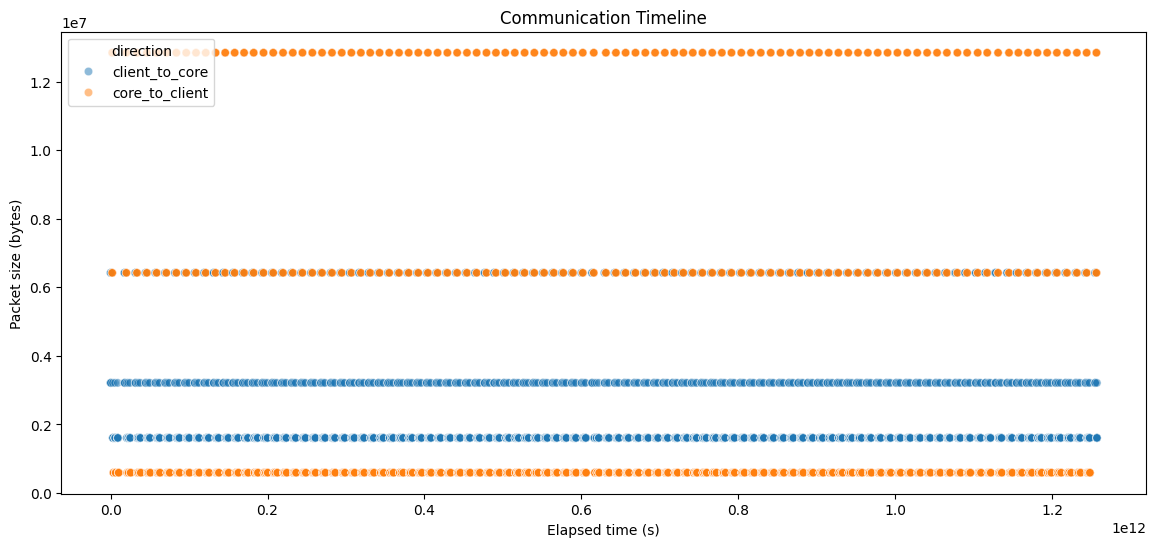

In [20]:
df["time"] = pd.to_datetime(
    df["timestamp"],
    unit="s"
)

df["elapsed_seconds"] = (
    df["timestamp"] - df["timestamp"].min()
)

plt.figure(figsize=(14, 6))

sns.scatterplot(
    data=df,
    x="elapsed_seconds",
    y="serialized_bytes",
    hue="direction",
    alpha=0.5
)

plt.xlabel("Elapsed time (s)")
plt.ylabel("Packet size (bytes)")
plt.title("Communication Timeline")

plt.show()


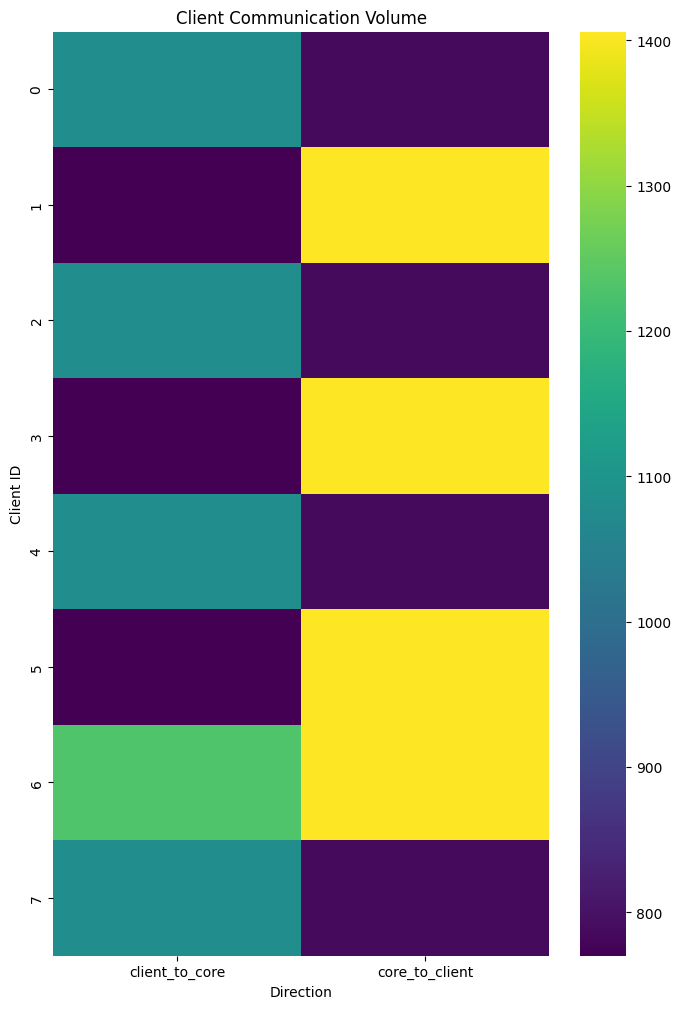

In [21]:
matrix = df.pivot_table(
    index="client_id",
    columns="direction",
    values="serialized_bytes",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(8, 12))

sns.heatmap(
    matrix / 1024**2,
    cmap="viridis"
)

plt.title("Client Communication Volume")
plt.xlabel("Direction")
plt.ylabel("Client ID")

plt.show()
